In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
file_path = r"C:\Users\hp\Desktop\Financial fraud detection\features_engineered_cleaned_final.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 99106
Columns: 40


,amount,hour,day_of_week,is_new_device,is_fraud,card_present,amount_log,is_weekend,account_age_days,risk_score,...,location_fraud_count,location_total_count,location_fraud_rate,location_mismatch,risk_score_amount,segment_encoded,merchant_category_encoded,transaction_type_encoded,location_x_encoded,location_y_encoded
0,807.91,16,5,False,0,True,6.695688,1,1394,0.520467,...,348,38593,0.009017,0,420.490493,2,2,3,8,4
1,734.39,7,4,False,0,False,6.600401,0,256,0.592291,...,156,20274,0.007695,0,434.972340,2,3,2,7,3
2,2080.84,21,3,False,0,False,7.641007,0,968,0.512422,...,348,38593,0.009017,0,1066.267170,0,0,1,8,4
3,2521.49,21,3,False,0,True,7.833002,0,2621,0.451517,...,156,20274,0.007695,0,1138.495849,2,0,0,7,3
4,1802.67,10,4,False,0,False,7.497579,0,2281,0.452063,...,162,19497,0.008309,0,814.921024,2,2,3,3,1


In [3]:
file_path = r"C:\Users\hp\Desktop\Financial fraud detection\alerts_cleaned_final.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 5000
Columns: 7


,alert_id,transaction_id,customer_id,alert_type,severity,timestamp,is_resolved
0,ALT_079681,TX_00079681,CUST_007451,High Amount,High,2026-08-17 00:15:46.462118,True
1,ALT_045971,TX_00045971,CUST_001232,New Device,Critical,2026-08-24 02:20:38.266080,True
2,ALT_095835,TX_00095835,CUST_002090,Unusual Time,Low,2026-08-29 18:36:50.122852,True
3,ALT_025868,TX_00025868,CUST_003270,New Device,Low,2026-08-27 17:50:33.578256,True
4,ALT_027966,TX_00027966,CUST_009474,Unusual Time,Medium,2026-09-02 14:15:34.057282,True


In [4]:
file_path = r"C:\Users\hp\Desktop\Financial fraud detection\customers_cleaned.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 10000
Columns: 10


,customer_id,segment,account_age_days,risk_score,email_verified,phone_verified,avg_monthly_transactions,avg_transaction_amount,device_count,location
0,CUST_000000,Retail,2332,0.697657,True,True,45,2064.757168,3,US
1,CUST_000001,Retail,531,0.588541,True,True,83,3040.637196,4,IN
2,CUST_000002,Business,1974,0.364320,True,True,9,2079.751870,1,US
3,CUST_000003,Retail,1852,0.454465,True,True,94,1135.531920,3,IN
4,CUST_000004,Business,2185,0.631022,False,True,94,3991.774005,2,IN


In [5]:
file_path = r"C:\Users\hp\Desktop\Financial fraud detection\fraud_cases_cleaned_final.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 1955
Columns: 8


,case_id,transaction_id,customer_id,fraud_amount,detection_time,fraud_type,status,investigator
0,FC_000021,TX_00000021,CUST_007238,134960.11,2026-08-06 06:31:27.377676,Suspicious Pattern,Under Review,INV_018
1,FC_000040,TX_00000040,CUST_005511,35381.62,2026-08-20 20:06:27.382354,Suspicious Pattern,Under Review,INV_013
2,FC_000122,TX_00000122,CUST_001316,28093.77,2026-08-19 01:25:27.401235,Location Mismatch,Under Review,NaN
3,FC_000128,TX_00000128,CUST_003935,194942.10,2026-09-01 09:40:27.402620,Device Anomaly,Confirmed,NaN
4,FC_000130,TX_00000130,CUST_002237,25678.05,2026-08-19 20:23:27.403100,Velocity,False Positive,INV_019


In [6]:
file_path = r"C:\Users\hp\Desktop\Financial fraud detection\paysim_transactions_cleaned.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 99106
Columns: 16


,transaction_id,customer_id,amount,timestamp,hour,day_of_week,location,merchant_category,is_new_device,device_id,ip_address,is_fraud,transaction_type,card_present,amount_log,is_weekend
0,TX_00000000,CUST_005287,807.91,2026-08-29 11:13:27.372050,16,5,US,Food,False,DEV_4390,48.164.21.194,0,wire,True,6.695688,1
1,TX_00000001,CUST_002180,734.39,2026-08-22 01:00:27.372684,7,4,UK,Retail,False,DEV_4068,212.254.99.120,0,online,False,6.600401,0
2,TX_00000002,CUST_006491,2080.84,2026-08-22 04:53:27.372963,21,3,US,E-commerce,False,DEV_1115,137.60.196.229,0,in-store,False,7.641007,0
3,TX_00000003,CUST_008714,2521.49,2026-09-02 18:32:27.373252,21,3,UK,E-commerce,False,DEV_2305,119.126.69.84,0,atm,True,7.833002,0
4,TX_00000004,CUST_004620,1802.67,2026-08-30 00:06:27.373504,10,4,IN,Food,False,DEV_4547,60.246.141.253,0,wire,False,7.497579,0


In [7]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(99106, 16)

Column Names:
['transaction_id', 'customer_id', 'amount', 'timestamp', 'hour', 'day_of_week', 'location', 'merchant_category', 'is_new_device', 'device_id', 'ip_address', 'is_fraud', 'transaction_type', 'card_present', 'amount_log', 'is_weekend']

Data Types:
transaction_id           str
customer_id              str
amount               float64
timestamp                str
hour                   int64
day_of_week            int64
location                 str
merchant_category        str
is_new_device           bool
device_id                str
ip_address               str
is_fraud               int64
transaction_type         str
card_present            bool
amount_log           float64
is_weekend             int64
dtype: object

First 5 Rows:


,transaction_id,customer_id,amount,timestamp,hour,day_of_week,location,merchant_category,is_new_device,device_id,ip_address,is_fraud,transaction_type,card_present,amount_log,is_weekend
0,TX_00000000,CUST_005287,807.91,2026-08-29 11:13:27.372050,16,5,US,Food,False,DEV_4390,48.164.21.194,0,wire,True,6.695688,1
1,TX_00000001,CUST_002180,734.39,2026-08-22 01:00:27.372684,7,4,UK,Retail,False,DEV_4068,212.254.99.120,0,online,False,6.600401,0
2,TX_00000002,CUST_006491,2080.84,2026-08-22 04:53:27.372963,21,3,US,E-commerce,False,DEV_1115,137.60.196.229,0,in-store,False,7.641007,0
3,TX_00000003,CUST_008714,2521.49,2026-09-02 18:32:27.373252,21,3,UK,E-commerce,False,DEV_2305,119.126.69.84,0,atm,True,7.833002,0
4,TX_00000004,CUST_004620,1802.67,2026-08-30 00:06:27.373504,10,4,IN,Food,False,DEV_4547,60.246.141.253,0,wire,False,7.497579,0


In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
transaction_id       0
customer_id          0
amount               0
timestamp            0
hour                 0
day_of_week          0
location             0
merchant_category    0
is_new_device        0
device_id            0
ip_address           0
is_fraud             0
transaction_type     0
card_present         0
amount_log           0
is_weekend           0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


In [9]:
display(df.describe())

,amount,hour,day_of_week,is_fraud,amount_log,is_weekend
count,99106.000000,99106.000000,99106.000000,99106.000000,99106.000000,99106.000000
mean,2650.749445,13.479931,3.002079,0.010706,7.265203,0.286764
std,2779.850929,4.650081,2.000786,0.102914,1.348570,0.452253
min,5.010000,0.000000,0.000000,0.000000,1.793425,0.000000
25%,696.232500,9.000000,1.000000,0.000000,6.547119,0.000000
50%,1907.015000,13.000000,3.000000,0.000000,7.553819,0.000000
75%,3892.467500,18.000000,5.000000,0.000000,8.267055,1.000000
max,34385.200000,23.000000,6.000000,1.000000,10.445411,1.000000


In [10]:
print("Fraud Distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud Percentage:")
print(df["is_fraud"].value_counts(normalize=True) * 100)

Fraud Distribution:
is_fraud
0    98045
1     1061
Name: count, dtype: int64

Fraud Percentage:
is_fraud
0    98.929429
1     1.070571
Name: proportion, dtype: float64


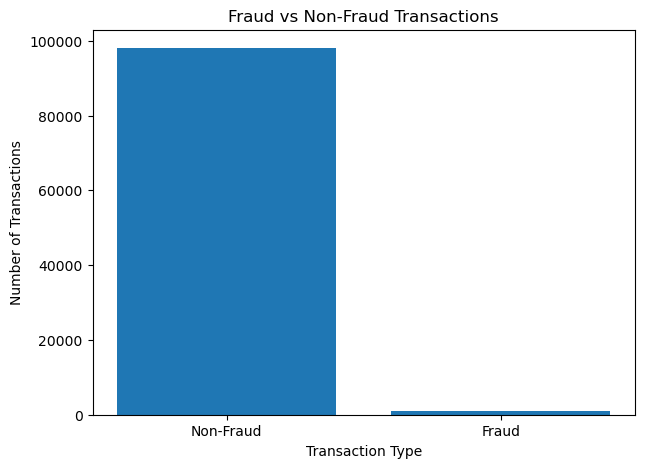

In [11]:
fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Fraud", "Fraud"],
    [fraud_counts.get(0, 0), fraud_counts.get(1, 0)]
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

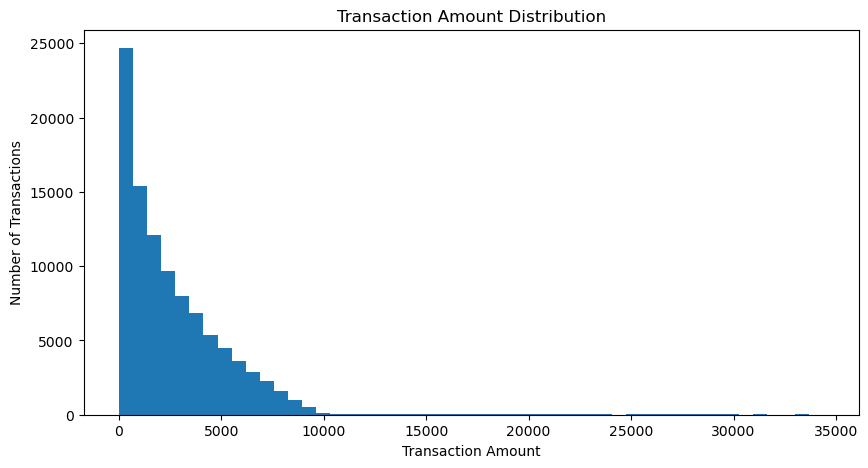

In [12]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

plt.figure(figsize=(10, 5))

plt.hist(
    df["amount"].dropna(),
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

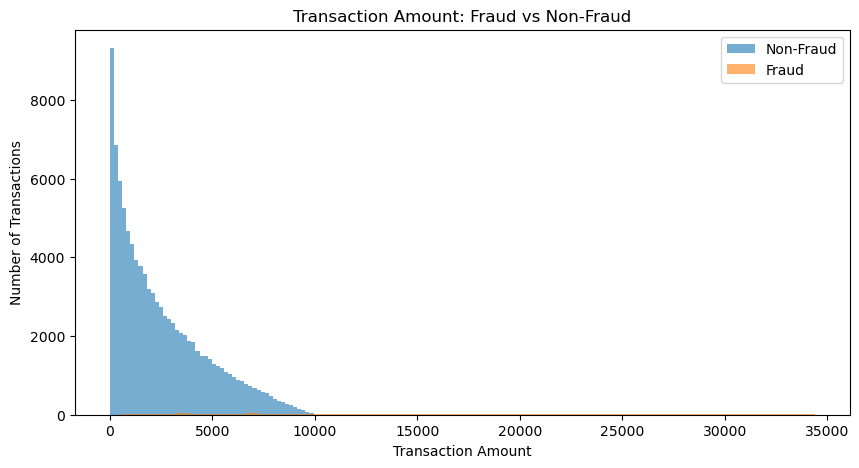

In [13]:
fraud_amount = df[df["is_fraud"] == 1]["amount"].dropna()
normal_amount = df[df["is_fraud"] == 0]["amount"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    normal_amount,
    bins=50,
    alpha=0.6,
    label="Non-Fraud"
)

plt.hist(
    fraud_amount,
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

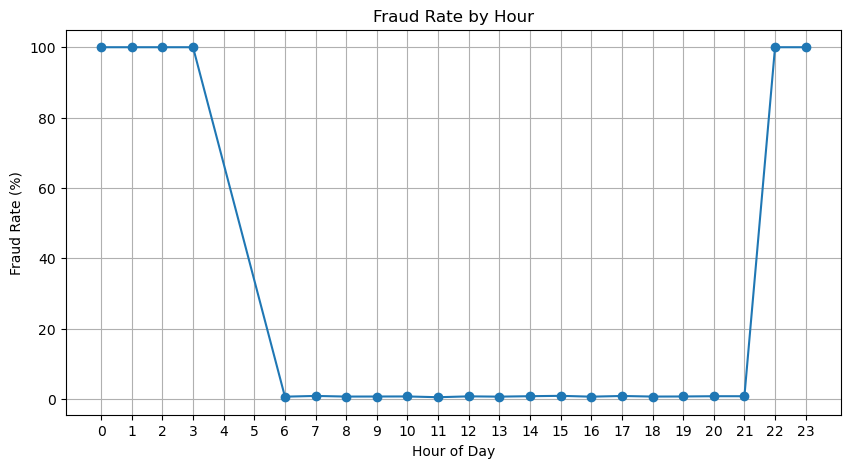

In [14]:
hour_fraud = df.groupby("hour")["is_fraud"].mean() * 100

plt.figure(figsize=(10, 5))

plt.plot(
    hour_fraud.index,
    hour_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))

plt.grid()
plt.show()

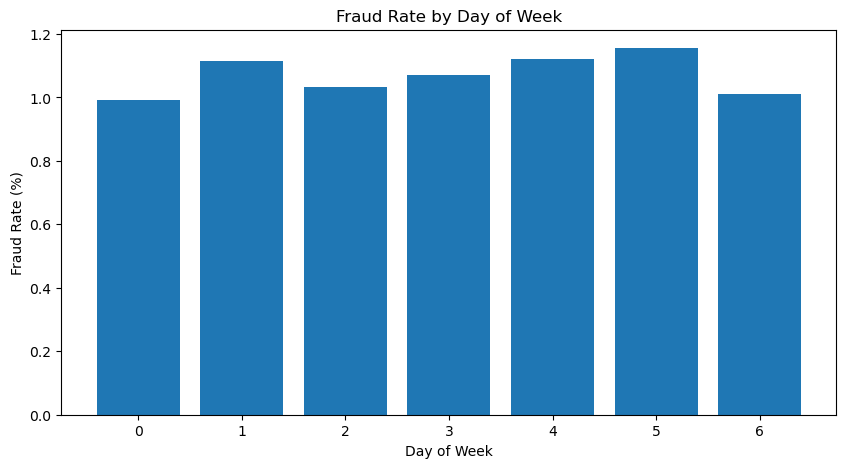

In [15]:
day_fraud = df.groupby("day_of_week")["is_fraud"].mean() * 100

plt.figure(figsize=(10, 5))

plt.bar(
    day_fraud.index.astype(str),
    day_fraud.values
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [16]:
numeric_df = df.select_dtypes(include=["number"])

correlations = numeric_df.corr()["is_fraud"].sort_values(ascending=False)

print("Correlation with Fraud:")
display(correlations)

Correlation with Fraud:


is_fraud       1.000000
amount         0.508661
amount_log     0.167923
day_of_week    0.001656
is_weekend     0.000812
hour          -0.031568
Name: is_fraud, dtype: float64

In [17]:
top_correlations = correlations.drop("is_fraud").abs().sort_values(ascending=False).head(10)

print("Top 10 Features Related to Fraud:")

display(top_correlations)

Top 10 Features Related to Fraud:


amount         0.508661
amount_log     0.167923
hour           0.031568
day_of_week    0.001656
is_weekend     0.000812
Name: is_fraud, dtype: float64

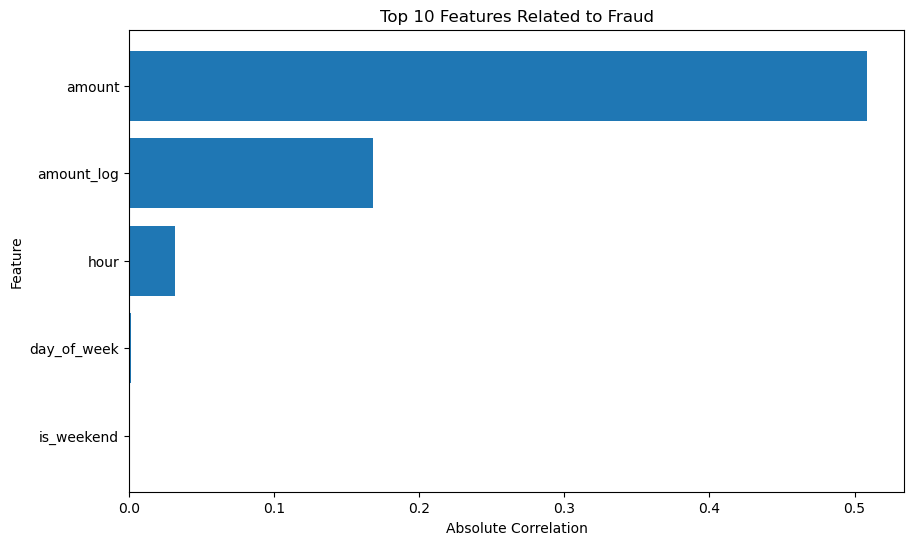

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_correlations.index,
    top_correlations.values
)

plt.title("Top 10 Features Related to Fraud")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [19]:
if "is_new_device" in df.columns:

    new_device_analysis = df.groupby("is_new_device")["is_fraud"].agg(
        ["count", "sum", "mean"]
    )

    new_device_analysis["fraud_rate_percent"] = (
        new_device_analysis["mean"] * 100
    )

    display(new_device_analysis)

,count,sum,mean,fraud_rate_percent
is_new_device,,,,
False,98783,738,0.007471,0.747092
True,323,323,1.000000,100.000000


In [26]:
print("Checking location_mismatch...")

print("Column exists:", "location_mismatch" in df.columns)

if "location_mismatch" in df.columns:
    print("\nLocation Mismatch Analysis:")

    location_analysis = df.groupby("location_mismatch")["is_fraud"].agg(
        count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )

    location_analysis["fraud_rate_percent"] = (
        location_analysis["fraud_rate"] * 100
    )

    display(location_analysis)

else:
    print("ERROR: location_mismatch column is not present.")

Checking location_mismatch...
Column exists: False
ERROR: location_mismatch column is not present.


In [27]:
print("Checking risk_score...")

print("Column exists:", "risk_score" in df.columns)

if "risk_score" in df.columns:

    print("\nRisk Score Statistics:")
    print(df["risk_score"].describe())

    plt.figure(figsize=(10, 5))

    plt.hist(
        df["risk_score"].dropna(),
        bins=30
    )

    plt.title("Risk Score Distribution")
    plt.xlabel("Risk Score")
    plt.ylabel("Number of Transactions")

    plt.show()

else:
    print("ERROR: risk_score column is not present.")

Checking risk_score...
Column exists: False
ERROR: risk_score column is not present.


In [29]:
print("Creating Risk Score Groups...")

if "risk_score" in df.columns:

    df["risk_score_group"] = pd.cut(
        df["risk_score"],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=[
            "0-20%",
            "20-40%",
            "40-60%",
            "60-80%",
            "80-100%"
        ],
        include_lowest=True
    )

    risk_fraud = df.groupby(
        "risk_score_group",
        observed=False
    )["is_fraud"].agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )

    risk_fraud["fraud_rate_percent"] = (
        risk_fraud["fraud_rate"] * 100
    )

    print("\nFraud Rate by Risk Score:")
    display(risk_fraud)

else:
    print("ERROR: risk_score column is not present.")

Creating Risk Score Groups...
ERROR: risk_score column is not present.


In [25]:
total_transactions = len(df)
total_fraud = int(df["is_fraud"].sum())
total_non_fraud = total_transactions - total_fraud
fraud_percentage = (total_fraud / total_transactions) * 100

print("=" * 50)
print("FINANCIAL FRAUD DETECTION - EDA SUMMARY")
print("=" * 50)

print(f"Total Transactions : {total_transactions:,}")
print(f"Fraud Transactions : {total_fraud:,}")
print(f"Non-Fraud          : {total_non_fraud:,}")
print(f"Fraud Rate         : {fraud_percentage:.2f}%")
print(f"Missing Values     : {df.isnull().sum().sum():,}")
print(f"Duplicate Rows     : {df.duplicated().sum():,}")

print("=" * 50)

FINANCIAL FRAUD DETECTION - EDA SUMMARY
Total Transactions : 99,106
Fraud Transactions : 1,061
Non-Fraud          : 98,045
Fraud Rate         : 1.07%
Missing Values     : 0
Duplicate Rows     : 0
